## Homework 7: Clustering & PCA with High-Dimensional Data
Objective:
To determine if K-Means or DBSCAN can accurately breast cancer patients into meaningful clusters and to evaluate the impact of PCA on high-dimensional clustering.
### Part 1: Initial Clustering 
Load the dataset (from sklearn.datasets import load_breast_cancer

data = load_breast_cancer )

drop the "target" column (Diagnosis). You should only have the 30 numerical features.
Standardization: Apply StandardScaler. This is mandatory as features have vastly different scales. Then Cluster the data using k-means and DBSCAN algorithm.
 - K-Means: Use the Elbow Method to suggest an optimal K, But if not 2, use K=2
 - DBSCAN: Attempt to find an appropriate eps and min_samples.
 - Metrics: Calculate the Silhouette Score for both
 
### Part 2: Dimensionality Reduction (PCA)
    - Perform PCA: Run PCA on your scaled 30-feature data.
    - Variance Analysis: Plot the Cumulative Explained Variance ratio.
    - Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.
    - Interpretation: Plot the heatmap of loading. Also identify which 3 original features contribute the most to Principal Component 1?
    
### Part 3: Clustering Using Principal Components
    - Reduce your dataset to the number of PCs identified in Part 2.
    - Run K-Means (K=2) on the PCA-transformed data.
    - Run DBSCAN on the PCA-transformed data.
    - Metric Comparison: Compare the Silhouette Score of the PCA-based clusters against the 30-feature clusters from Part 1.
    
   
### Part 4: Visual Validation
    - Scatter Plot: Create a 2D plot using PC1 and PC2, Color the points using your K-Means labels (If your Kmeans .
    - Create a second version of the plot colored by the original labels (target).
    - How closely did the unsupervised K-Means clusters match the actual medical diagnosis? 

Load packages and data. 

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

#load breast cancer data and create dataframe
raw_data = load_breast_cancer()
df = pd.DataFrame(raw_data.data, columns = raw_data.feature_names)
# df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Part 1: Intial Clustering

In [12]:
# Standardize data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)
#print(x_scaled)

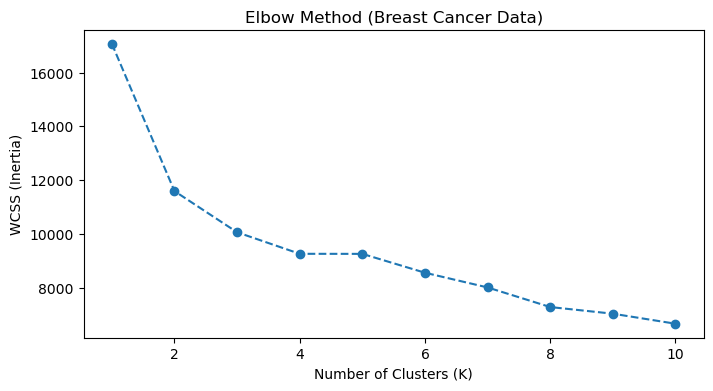

In [13]:
#Explore K-Means with Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k,  random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method (Breast Cancer Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [15]:
#perform k-means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)

In [16]:
#perform DBSCAN
dbscan = DBSCAN(eps=5.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

In [17]:
#calculate the silhouette for both methods

kmeans_silhouette = silhouette_score(x_scaled, kmeans_labels)

dbscan_silhouette = silhouette_score(x_scaled, dbscan_labels)

print(f"The K-Means Silhouette Score is: {kmeans_silhouette: .3f}")
print(f"The DBSCAN Silhouette Score is: {dbscan_silhouette: .3f}")


The K-Means Silhouette Score is:  0.345
The DBSCAN Silhouette Score is:  0.481


Part II: Dimentionality Reduction (PCA)

In [18]:
#Run PCA on the scaled 30-feature data. 
from sklearn.decomposition import PCA

pca = PCA()
x_pca = pca.fit_transform(x_scaled)

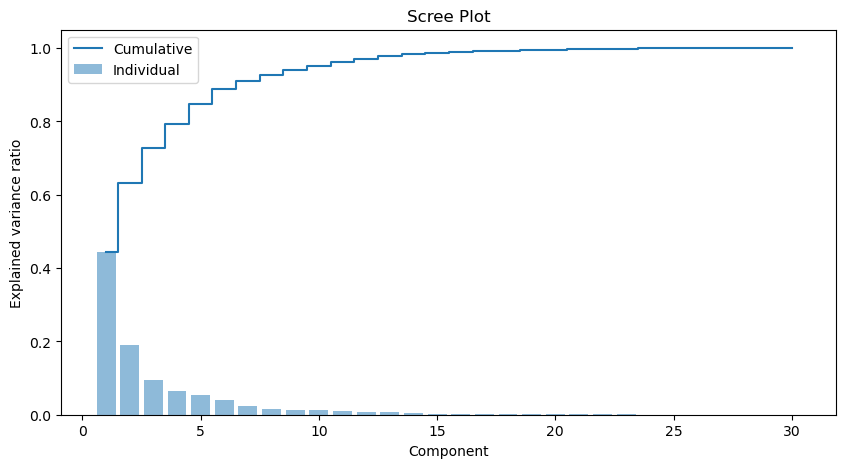

In [21]:
#Variance Analysis: Plot the cumulative explained variance ratio.

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_, alpha=0.5, label='Individual')
plt.step(range(1, len(pca.explained_variance_ratio_)+1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Cumulative')
plt.ylabel('Explained variance ratio'); plt.xlabel('Component'); plt.title('Scree Plot'); plt.legend(); plt.show()


- Identify the minimum number of Principal Components (PCs) needed to capture ~85% of the variance.

Based on the variance analysis, the number of PCs needed to capture 85% of the variance is six. 

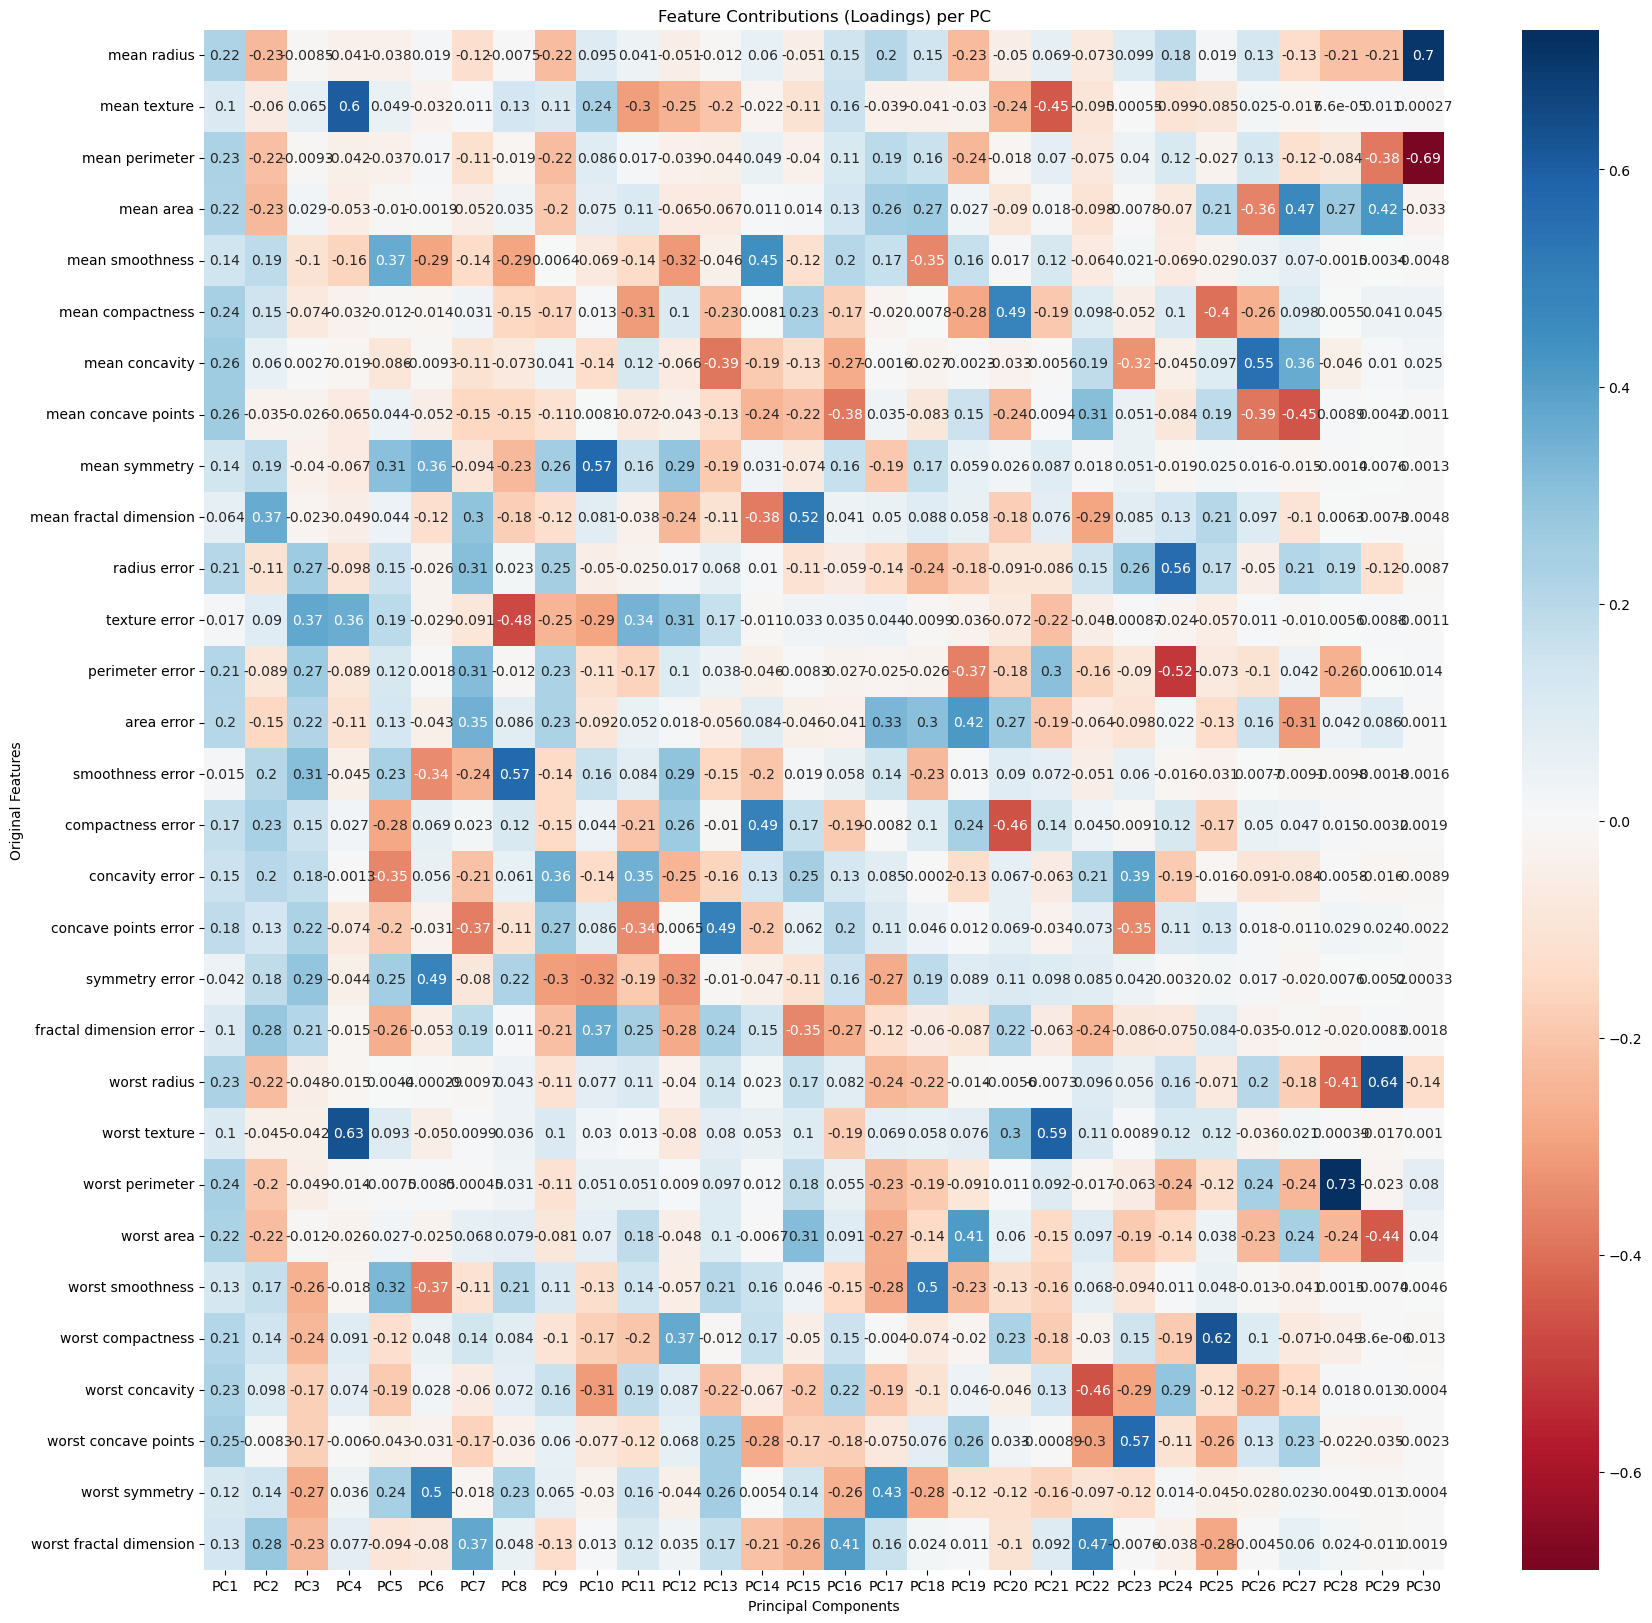

In [25]:
#Plot the heatmap of loading. 

features = list(df.columns)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=features
)

# Plotting the Heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title('Feature Contributions (Loadings) per PC')
plt.ylabel('Original Features')
plt.xlabel('Principal Components')
plt.show()

The three features that contribute most to PC1 are mean concave points(.26), mean concavity(.26), and worst concave points(.25). 

Part III: Clustering Using Principle Components 

In [29]:
# Reduce the dataset to 6 PCs

reduced_pcs = PCA(n_components = 6)
x_reduced = reduced_pcs.fit_transform(x_scaled)

# Run K-means on PCA transformed data

km_reduced = KMeans(n_clusters=2, random_state=42)
km_reduced_labels = km_reduced.fit_predict(x_reduced)
km_reduced_sscore = silhouette_score(x_reduced, km_reduced_labels)

# Run DBSCAN on PCA data

db_reduced = DBSCAN(eps=5, min_samples=5)
db_reduced_labels = db_reduced.fit_predict(x_reduced)
db_reduced_sscore = silhouette_score(x_reduced, db_reduced_labels) 

print(f"New K-Means Silhouette Score: {km_reduced_sscore: .3f}")
print(f"New DBSCAN Silhouette Score: {db_reduced_sscore: .3f}")


New K-Means Silhouette Score:  0.377
New DBSCAN Silhouette Score:  0.556


After PCA, the K-Means Silhouette Score improved, .345 to .377. The DBSCAN Silhouette Score also improved, from .4810 to .556. 

Part IV: Visual Validation

Text(0, 0.5, 'Principal Component 2')

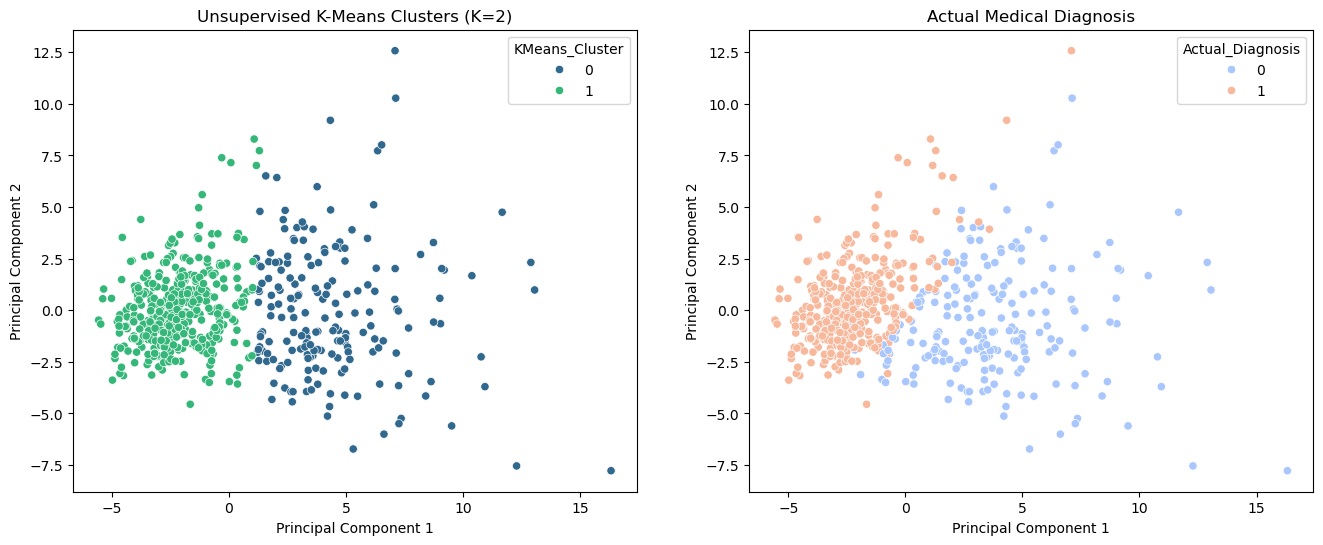

In [36]:
# Scatter Plot: 2D plot using PC1 and PC2

plt_df = pd.DataFrame(x_reduced[:, :2], columns=['PC1', 'PC2'])
plt_df['KMeans_Cluster'] = km_reduced_labels
plt_df['Actual_Diagnosis'] = raw_data['target']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(data=plt_df, x='PC1', y='PC2', hue='KMeans_Cluster', palette='viridis', ax=ax1)
ax1.set_title('Unsupervised K-Means Clusters (K=2)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')

# Plot Actual Medical Diagnosis
sns.scatterplot(data=plt_df, x='PC1', y='PC2', hue='Actual_Diagnosis', palette='coolwarm', ax=ax2)
ax2.set_title('Actual Medical Diagnosis')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

Based on a visual examination, the unsupervised K-Means clusters matched the actual diagnosis pretty well. The two plots look very similar. 